---
title: "Lab 1 - PECARN TBI Data, Stat 215A, Fall 2026"
author: "June Park"
date: "September 20, 2026"
format:
  pdf:
    <!-- fig-format: png
    fig-dpi: 300
    out-width: "50%"
    fig-align: center -->
    include-in-header:
      text: |
        \usepackage{graphicx}
        \usepackage{adjustbox}
        \usepackage{caption}
        \captionsetup[figure]{font=tiny, skip=4pt}
        <!-- \usepackage{titlesec}
        \titleformat{\section}{\normalfont\Large\bfseries}{\thesection}{1em}{}
        \titleformat{\subsection}{\normalfont\large\bfseries}{\thesubsection}{1em}{}
        \titleformat{\subsubsection}{\normalfont\normalsize\bfseries}{\thesubsubsection}{1em}{}
        \titlespacing*{\section}{0pt}{8pt}{3pt}
        \titlespacing*{\subsection}{0pt}{6pt}{2pt}
        \titlespacing*{\subsubsection}{0pt}{4pt}{2pt} -->
execute:
  echo: false
---

# 1 Introduction

Unidentified traumatic brain injury (TBI) is a leading cause of death and disability in children worldwide, urging clinicians to discover them promptly after hospital admission. To meet such demands, CT scans have rapidly become a popular method for identifying TBIs due to their efficacy. They are quick, non-invasive, and can uncover acute hemorrhages and hematomas that require immediate neurosurgery[1]. Although CT scans are unable to capture all brain injuries, its reliability in such dire situations has driven it to overuse.

Overuse of CT poses a risk to patients due to the emitted ionising radiation that can cause lethal malignancies. For children, who often undergo CT despite only having minor head trauma, CT procedures can be an unnecessary hazard. To minimize these concerns, Kuppermann et al.[2] devised a set of prediction rules to identify children at low risk of clinically-important TBI. In this report, we will be assessing the stability of their rules by testing their results on perturbations of their cleaned data. Doing so will allow us to validate the rules as a concrete industry standard for assessing children with head trauma to avoid the unnecessary risks of CT procedures. Furthermore, our analysis may reveal that other factors not considered by the rules established by Kupperman et al.[2] may improve the identification process. Throughout the rest of this report, we will be describing the data, our data cleaning procedure (highlighting the impact of judgment calls during the cleaning process), and our reasoning through data exploration. Following the data inspection, we will validate the PECARN study's predictive rules by implementing two models and comparing the results.

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import clean

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from IPython.display import Latex, display

# 2 Data

## 2.1 Data Collection

The data provided by the PECARN study contains data on 43,400 patients under the age of 18 with head trauma from 25 North Americans emergency departments. Data was collected from June 2004 to September 2006 for children presented within 24 hours of head trauma, excluding those with trivial injury mechanisms, known brain tumors, pre-existing nuerological disorders, no signs or symptoms of head trauma, or have had nueroimaging at an outside hospital prior to being transferred. For each of the 43,400 patients are 125 variables ranging from various symptoms, such as altered mental status and neurological deficit, symptom severity scores, administrative variables, demographics, and the outcome variable. Both in our study and the PECARN study, the outcome variable is an indicator for clinically-important TBI (ciTBI), defined as the patient having one of the following: 1) neurological surgery, 2) intubation for at more than 24 hours for head trauma, 3) death due to TBI or in the emergency department, or hospital admission for at least two nights due to head injury or TBI. Given that a sufficiently ample health dataset is often difficult to obtain due to privacy concerns, this rich dataset allows a thorough analysis of factors that indicate high-risk of TBI for young patients with greater statistical power.

## 2.2 Data Cleaning

In the data cleaning process, we aim to identify abnormalities to remove and inconsistencies to correct prior to analysis. We begin by isolating the participants who fit the crteria of those analyzed in the PECARN study. Recall that the purpose of the study was to identify younger children at low-risk of TBI. Hence, we filter for subjects who whose Glasgow Coma Scale (GCS) scores are either 14 or 15 and subjects who have a record of their ciTBI status. Doing so reduced our total number of samples to 42,412, which was split into training, validation, and test sets of size 29,668, 6,362 and 6,362, respectively. The three datasets were cleaned separately to avoid data leakage.

In [2]:
# Get File Directory
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)
data_path = os.path.join(parent_dir,"data")

data_org = pd.read_csv(os.path.join(data_path, "TBI PUD 10-08-2013.csv"))
data = data_org.copy()

In [3]:
# Split the data prior to data cleaning to avoid data leakage.
# Note: We cannot split the data by time of arrival due to the random
# indexing of the patients. Hence, we simply split the data randomly.
data = data[(data["GCSGroup"] == 2) & (data["PosIntFinal"].isin([0,1]))]
data_split_train, data_split_val = train_test_split(data, test_size=0.3, random_state=42)
data_split_val, data_split_test = train_test_split(data_split_val, test_size=0.5, random_state=24)

Before we begin describing our data cleaning procedure, we first justify a key assumption made that shapes our approach. The data for each patient appears to have been recorded at different timepoints. In the dataset, there are variables noting the symptoms, the ordering of a CT scan, and the results of a CT scan. Although it may be feasible that the data was all recorded at the end of the emergency department visit, there are inconsistencies between the symptoms and the reasons for ordering a CT scan, and inconsistencies between the ordering of a CT scan and actually having completed the CT scan. We believe these inconsistencies may be the result of updated information between the times of collecting initial data, reviewing the data in preparation for a potential CT scan, and the final check at completion. These inconsistencies will be explored further below.

Inspecting our data revealed a large quantity of missing values. We first address the variables representing the various symptoms recorded and the variables that marked the specific cause of the symptom. For example, a pair of such variables found in the dataset are `AMS` and `AMSAgitated`, where `AMS` indicates if there are signs of an altered mental status in general and `AMSAgitated` indicates agitation. From this point on, we will refer to such variables as the main symptom variable and the sub symptom variable. For all of the 42,412 subjects, there were no missing values for any of the sub symptom variables, however, there were numerous missing values for all of the main symptom variables (Table 1).

In [4]:
#| output: true
#| fig-align: center
#| lst-cap: "Logistic Regression Coefficients Across Age Groups"
#| attr-output: 'style="font-size: 0.5em;"'
features = ["AMS", "SFxBas", "Clav", "NeuroD", "Seiz", "OSI", "CTSed", "Vomit", "Hema",]

na_counts_train = data_split_train[features].isna().sum()
na_counts_val = data_split_val[features].isna().sum()
na_counts_test = data_split_test[features].isna().sum()

len_train = len(data_split_train)
len_val = len(data_split_val)
len_test = len(data_split_test)

na_summary = pd.DataFrame({"Feature": features,
                           "Train Missing": [f"{count:,} ({count / len_train:.2%})" for count in na_counts_train],
                           "Val Missing": [f"{count:,} ({count / len_val:.2%})" for count in na_counts_val],
                           "Test Missing": [f"{count:,} ({count / len_test:.2%})" for count in na_counts_test]})

latex_table = na_summary.to_latex(index=False, escape=True)
shrunk_latex = f"""\\begin{{table}}[h]\\centering\\scriptsize{latex_table}\\captionsetup{{font=tiny}}\\caption{{NA Count for Main Symptom Variables}}\\end{{table}}"""

display(Latex(shrunk_latex))

<IPython.core.display.Latex object>

The dataset was organized by the PECARN cohort such that the sub symptom variables would have values of 0 or 1 (false or true) if the main symptom variables were marked as 1, and 92 otherwise. Using this information, we impute the missing main symptom variable values with 1 if the sub symptom variables had values of 1 or 0, and 0 if the sub symptoms variables had a value of 92.The alternative to this method was to rely on variables which indicated whether the symptom was a primary reason for ordering a CT scan for a subject. The data for these variables were collected in a similar fashion in which if the ct scan was ordered, the indicator variables had values of 0 or 1, 92 otherwise. Intuitively, we would assume that these indicator variables would contain the same information as the main symptom variables, however, further inspection revealed several inconsistencies. 

Firstly, we found disagreements between the main symptom variables and the indicator variables. This was true even for the patients who we did not impute the main symptom variables for. Given our assumption that the data was recorded at different times, it may be possible that prior to deciding whether a CT scan should be ordered or not, there were updates to the patient's symptoms. Now, this would imply that the indicator variables are more faithful to the truth, however, this issue is further complicated by the fact that there are also inconsistencies between ordering a CT scan and actually proceeding with the CT scan. The indicator variables determine whether a CT scan was ordered, but because the ordering and the completion of the CT scans do not always coincide (i.e. a CT scan was ordered but never accomplished), we have reason to believe that there may have been another update to the patient's symptoms that reflects this difference. Furthermore, the indicator variable being marked as true only indicates that the symptom is a primary reason for the CT scan order, hence it does not indicate whether the patient truly has said symptom or not. Due to the uncertainty surrounding these indicator variables, we chose to use the main symptom variables as the ground truth for our imputations rather than the indicator variables. We will revisit the effects of this assumption later in this report.

The only other variable we chose to impute values for was `High_impact_InjSev`, which indicates the severity of the injury. The original study determines this based on `InjuryMech` (injury mechanism), ranging from getting struck by a moving vehicle to light falls from short heights. We found that the injury mechanism variable had 283 missing entries, and injury severity had 313. Using the non-missing injury mechanisms, we discovered that all 30 of the extra missing entries from the injury severity variable corresponded to "pedestrian struck by moving vehicle." The documentation for the data explictely states that a "pedestrian or bicyclist without helmet struck by a motorized vehicle" is categorized as a high severity, which suggests that our missing values should be imputed as so. However, we found that of the patients we had data on for these two variables, there were a mix of medium and high severities for those struck by a moving vehicle (Figure 1).

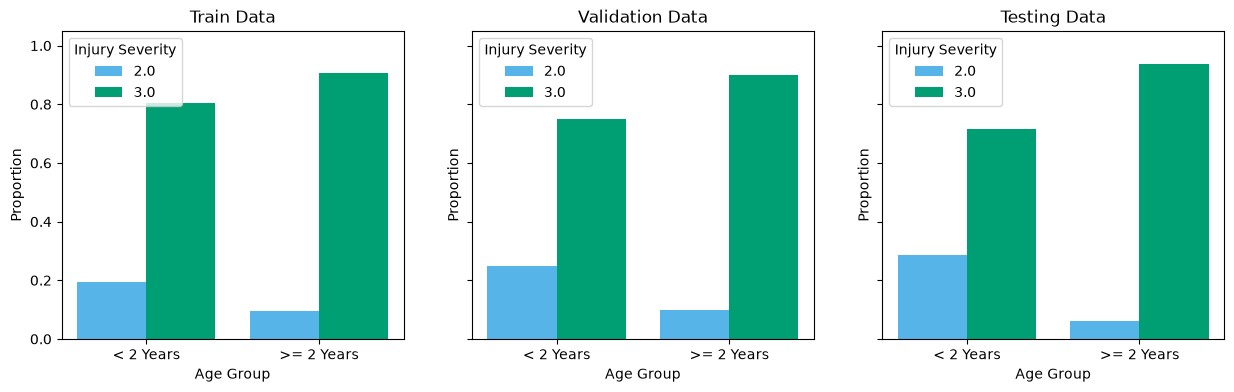

In [5]:
#| fig-cap: "Proportion of injury severity scores by age group for InjuryMech = 2"
def get_proportions(df):
    """ 
    
    Fetches proportions of injury severity scores for injury mechanism = 2 (struck by moving vehicle) grouped by age group.
    
    Args:
        df (pd.DataFrame): Dataset to get proportions from.
        
    Returns:
        (pd.DataFrame): Dataframe with rows representing age groups, columns representing injury severity levels, and values representing conditional proportions.
    """
    sub = df[df["InjuryMech"] == 2]
    return (sub.groupby("AgeTwoPlus")["High_impact_InjSev"].value_counts(normalize=True).unstack(fill_value=0))


train_prop = get_proportions(data_split_train)
val_prop = get_proportions(data_split_val)
test_prop = get_proportions(data_split_test)

age_groups = train_prop.index.tolist()
severities = train_prop.columns.tolist()

x = np.arange(len(age_groups))
width = 0.8 / len(severities)

colors = ["#56B4E9", "#009E73"]
color_map = {severity: colors[i % len(colors)] for i, severity in enumerate(severities)}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
datasets = [(train_prop, "Train Data"), (val_prop, "Validation Data"), (test_prop, "Testing Data")]

age_label_map = {1: "< 2 Years", 2: ">= 2 Years"}

for ax_idx, (prop_df, title) in enumerate(datasets):
    ax = axes[ax_idx]

    for i, severity in enumerate(severities):
        offset = (i - len(severities) / 2) * width + width / 2
        values = prop_df[severity].reindex(age_groups, fill_value=0).values
        ax.bar(x + offset, values, width, label=severity, color=color_map[severity])

    ax.set_title(f"{title}")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Proportion")
    ax.set_xticks(x)
    ax.set_xticklabels([age_label_map.get(ag, str(ag)) for ag in age_groups])
    
    ax.set_ylim(0, 1.05)
    ax.legend(title="Injury Severity", loc="upper left")

We speculate that the existence of these medium severity scores are a result of being struck by non-motor vehicles or the fortunate event that the patient was wearing a helmet. Considering this information, we chose to impute the values by using the proportion of those with medium and high severity scores for each age group in the training data as the probability for being assigned a medium or high severity score. 

We decided that imputing any other variables would be infeasible, as imputing symptoms directly without any indication of their presence could pollute our data and result in inaccurate and dangerous conclusions. To conclude our data cleaning and preprocessing, we removed all variables except for sixteen indicating the following: injury severity, altered mental status, basilar skull fracture, clavicle trauma, neurological deficit, seizure, other substantial injuries, vomiting, scalp hematoma, palpable skull fracture, loss of consciousness, age group, gender, total GCS score, and ciTBI. We also chose to flip the values for acting normal to obtain a new variable called `acting_abnormally` such that a "positive" value for any symptom variable indicates a detrimental symptom. All participants with missing values from the remaining variables were removed to avoid making conclusions with a lack of information on such symptoms, resulting in final training and validation set sizes of 28,374 and 7,062, respectively.

In [6]:
train_data, val_data, test_data = clean.clean_data(data_split_train, data_split_val, data_split_test, False)

## 2.3 Data Exploration

In [7]:
symptom_vars = [
    "altered_mental_status", "basilar_skull_fracture", "clavicle_trauma",
    "neurological_deficit", "seizure", "other_substantial_injuries",
    "vomiting", "scalp_hematoma", "palpable_skull_fracture",
    "loss_of_consciousness", "acting_abnormally"
]
clean_symptom_map = {var: var.replace("_", " ").title() for var in symptom_vars}

train_data["symptom_count"] = train_data[symptom_vars].sum(axis=1)
train_data["symptom_bin"] = train_data["symptom_count"].astype(str)

severities = ["Low", "Medium", "High"]
age_groups = sorted(train_data["age_group"].dropna().unique())

x_pos = np.arange(len(severities))
bar_width = 0.35
sev_colors = ["#56B4E9", "#009E73", "yellow"]

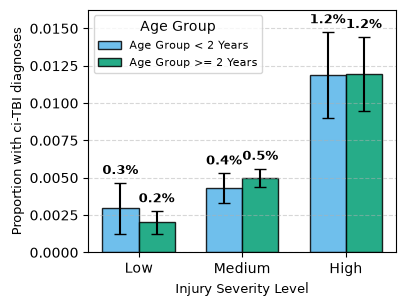

In [8]:
#| fig-align: "center"
#| fig-cap: "Proportion of ci-TBI diagnoses per injury severity score stratified by age group"

grouped_tbi = train_data.groupby(["injury_severity", "age_group"])["ci_tbi"].agg(["mean", "std", "count"])
grouped_tbi["sem"] = grouped_tbi["std"] / np.sqrt(grouped_tbi["count"])

fig, ax = plt.subplots(figsize=(4, 3))

for idx, age in enumerate(age_groups):
    offset = (idx - 0.5) * bar_width
    tbi_means = [grouped_tbi.loc[(sev, age), "mean"] if (sev, age) in grouped_tbi.index else 0 for sev in severities]
    tbi_sems = [grouped_tbi.loc[(sev, age), "sem"] if (sev, age) in grouped_tbi.index else 0 for sev in severities]

    bars = ax.bar(x_pos + offset, tbi_means, yerr=tbi_sems, width=bar_width, label=f"Age Group {age}", color=sev_colors[idx % len(sev_colors)], edgecolor="black", capsize=4, alpha=0.85)

    for bar, sem in zip(bars, tbi_sems):
        h = bar.get_height()
        if not np.isnan(h) and h >= 0:
            top_y = h + (sem if not np.isnan(sem) else 0)
            ax.annotate(f"{h:.1%}", xy=(bar.get_x() + bar.get_width() / 2, top_y), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold", bbox=dict(boxstyle="square,pad=0", fc="white", ec="none", alpha=0.7))

ax.set_xlabel("Injury Severity Level", fontsize=9)
ax.set_ylabel("Proportion with ci-TBI diagnoses", fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(severities)
ax.legend(title="Age Group", fontsize=8, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

max_y = max([h + s for h, s in zip(grouped_tbi["mean"].dropna(), grouped_tbi["sem"].dropna())])
ax.set_ylim(0, max_y * 1.1)

plt.tight_layout(pad=0.5)
plt.show()

Given that the symptoms and ciTBI depend on the severity of the child's injury, we wanted to explore the relationship between injury severity and the risk of ciTBI. As we would expect, plotting a bar plot of the proportion of children with ciTBI vs injury severity stratified by age group (< 2 years and > 2 years), reveals a positive exponential relationship (Figure 2). Although there isn't a significant difference in proportion of ciTBI diagnoses between injury severity levels of low and medium for the younger age group, clearly, a more severe injury is likely to have a greater chance at inflicting TBI.

Following this, we believed it to be reasonable that with greater severity score levels, we would observe a greater number of symptoms (among altered mental status, basilar skull fracture, clavicle traume, neurological deficit, seizures, vomiting, scalp hematoma, palpable skull fracture, loss of consciousness, acting abnormally, and other substantial injuries). Interestingly, we discovered that the average number of positive symptoms per severity level were similar. Furthermore, the distribution of the number of symptoms were also similar (Figure 3).

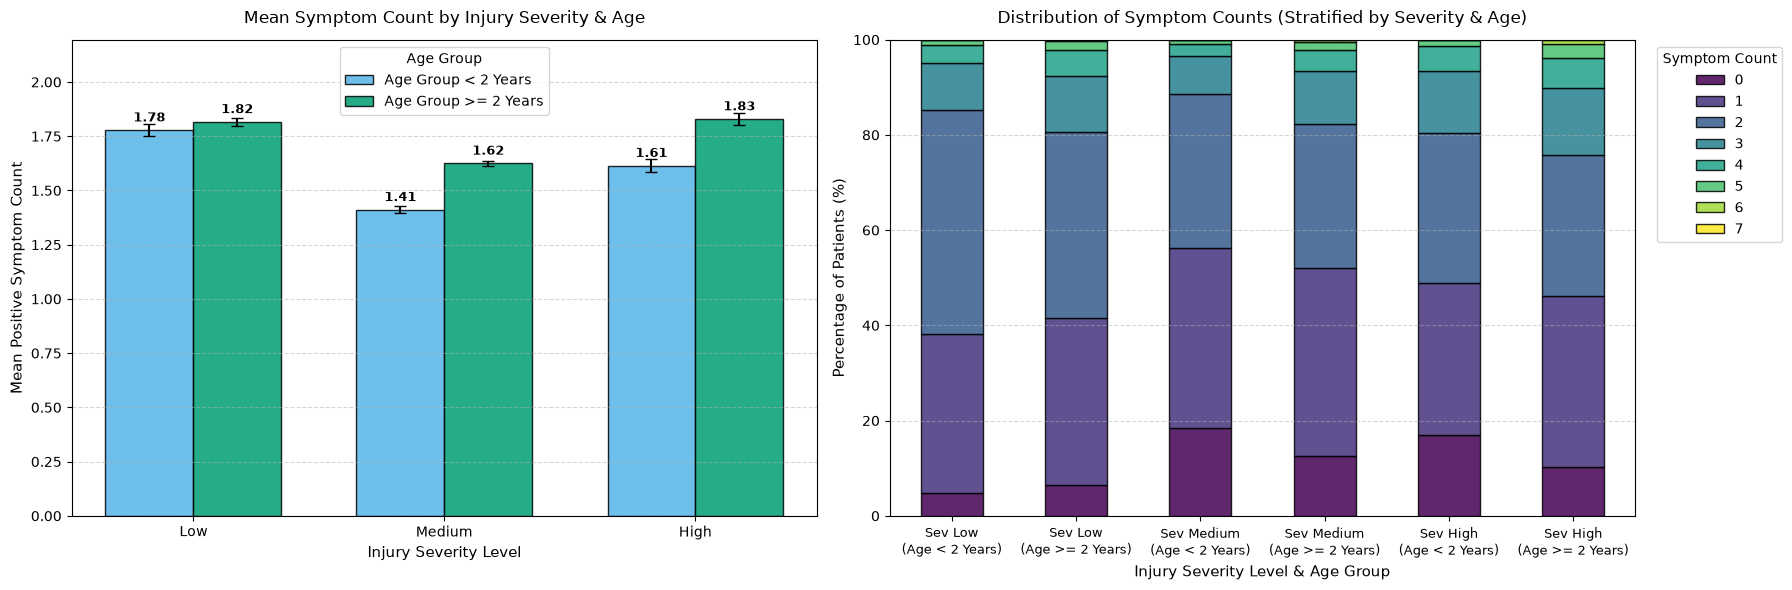

In [9]:
#| fig-cap: "Comparative Symptom Profiles Across Injury Severities and Age Groups"
grouped_symptom = train_data.groupby(["injury_severity", "age_group"])["symptom_count"].agg(["mean", "std", "count"])
grouped_symptom["sem"] = grouped_symptom["std"] / np.sqrt(grouped_symptom["count"])

dist_stratified = (pd.crosstab([train_data["injury_severity"], train_data["age_group"]], train_data["symptom_bin"], normalize="index") * 100)
ordered_index = pd.MultiIndex.from_product([severities, age_groups], names=["injury_severity", "age_group"])
dist_stratified = dist_stratified.reindex(ordered_index).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for idx, age in enumerate(age_groups):
    offset = (idx - 0.5) * bar_width
    means = [grouped_symptom.loc[(sev, age), "mean"] if (sev, age) in grouped_symptom.index else 0 for sev in severities]
    sems = [grouped_symptom.loc[(sev, age), "sem"] if (sev, age) in grouped_symptom.index else 0 for sev in severities]

    bars = ax1.bar(x_pos + offset, means, yerr=sems, width=bar_width, label=f"Age Group {age}", color=sev_colors[idx % len(sev_colors)], edgecolor="black", capsize=4, alpha=0.85)

    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax1.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width() / 2, h), xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax1.set_title("Mean Symptom Count by Injury Severity & Age", fontsize=12, pad=12)
ax1.set_xlabel("Injury Severity Level", fontsize=11)
ax1.set_ylabel("Mean Positive Symptom Count", fontsize=11)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(severities)
ax1.legend(title="Age Group", fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_ylim(0, max(grouped_symptom["mean"].dropna()) * 1.20)

dist_stratified.plot(kind="bar", stacked=True, ax=ax2, colormap="viridis", edgecolor="black", alpha=0.85)

strat_labels = [f"Sev {sev}\n(Age {age})" for sev, age in dist_stratified.index]

ax2.set_title("Distribution of Symptom Counts (Stratified by Severity & Age)", fontsize=12, pad=12)
ax2.set_xlabel("Injury Severity Level & Age Group", fontsize=11)
ax2.set_ylabel("Percentage of Patients (%)", fontsize=11)
ax2.legend(title="Symptom Count", bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.set_xticklabels(strat_labels, rotation=0, fontsize=9.5)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Because the data are restricted to patients with GCS scores of 14-15, this uniform distribution likely reflects an overrepresenation of low-risk, mildly symptomatic patients in the emergency departments. This observation underscores the original motive of the PECARN study. Clinicians often order CT scans due to defensive practice or out of parental concern over a single symptom, thus, it is necessary to identify which specific symptoms are most indicative of ciTBI to avoid unnecessary imaging.

# 3 Findings

## 3.1 First Finding

To obtain a better understanding of the symptoms, we plotted the proportion of symptoms stratified by injury severity (Figure 4). The distribution of symptoms is rather intuitive, as the common symptoms are easily observable by a parent, supporting the hypothesis of overadmittance due to parental concern. On the other hand, symptoms such as neurological deficit and basilar skull fracture are more difficult to diagnose, and a palpable skull fracture can be indistinguishable due to swelling. 

Among the symptoms with significant differences in proportions across severity levels, other substantial injuries shows a strong positive correlation with injury severity, reflecting the broader physical impact of injury mechanisms. Conversely, scalp hematoma was most prevalent for those classified as having low severity injuries (54.7%), further emphasizing that minor accidents frequently prompt emergency department visits. Due to these relationships, evaluating which symptoms are most indicative of ciTBI (shown below) is likely to show that the less frequent, clinican-identified symptoms have the strongest positive correlation with ciTBI diagnosis.

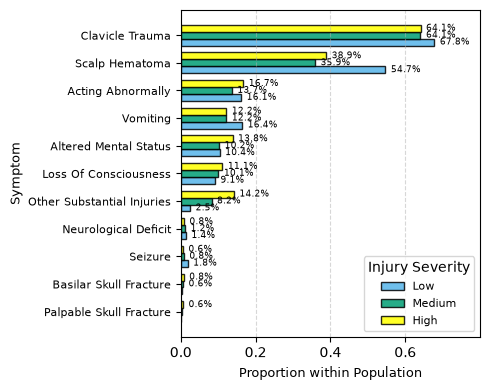

In [10]:
#| fig-align: "center"
#| fig-cap: "Prevalence of Clinical Symptoms Stratified by Injury Severity"
records = []
for sev in severities:
    sub_df = train_data[train_data["injury_severity"] == sev]
    for var in symptom_vars:
        prop = sub_df[var].mean()
        records.append({"symptom": var, "injury_severity": sev, "proportion": float(prop)})

prop_df = pd.DataFrame(records)
overall_order_prop = (prop_df.groupby("symptom")["proportion"].mean().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(5, 4))
y_positions = np.arange(len(overall_order_prop))
bar_height = 0.25

for idx, sev in enumerate(severities):
    sev_data = (prop_df[prop_df["injury_severity"] == sev].set_index("symptom").reindex(overall_order_prop).reset_index())
    offset = (idx - (len(severities) - 1) / 2) * bar_height

    bars = ax.barh(y_positions + offset, sev_data["proportion"], height=bar_height, label=f"{sev}", color=sev_colors[idx % len(sev_colors)], edgecolor="black", alpha=0.85)

    for bar in bars:
        width = bar.get_width()
        if not np.isnan(width) and width > 0.005:
            ax.annotate(f"{width:.1%}", xy=(width, bar.get_y() + bar.get_height() / 2.0), xytext=(4, 0), textcoords="offset points", ha="left", va="center", fontsize=6.5)

clean_labels = [clean_symptom_map[var] for var in overall_order_prop]
ax.set_yticks(y_positions)
ax.set_yticklabels(clean_labels, fontsize=8)
ax.set_xlabel("Proportion within Population", fontsize=9)
ax.set_ylabel("Symptom", fontsize=9)
ax.legend(title="Injury Severity", fontsize=8)
ax.grid(axis="x", linestyle="--", alpha=0.5)

max_prop = prop_df["proportion"].max()
if not np.isnan(max_prop) and max_prop > 0:
    ax.set_xlim(0, max_prop * 1.18)

plt.tight_layout()
plt.show()

## 3.2 Second Finding

Plotting the symptom variables vs proportion of ciTBI diagnoses by age group confirms our speculation (Figure 5). The two most uncommon symptoms, palpable skull fracture and basilar skull fracture, have the highest proportion of patients diagnosed with ciTBI. Although the proportions for the other variables vary marginally between the two age groups, altered mental status appears to be the third most prevalent indicator for ciTBI. This further supports our earlier reasoning on the prevalence of easily-observable symptoms.

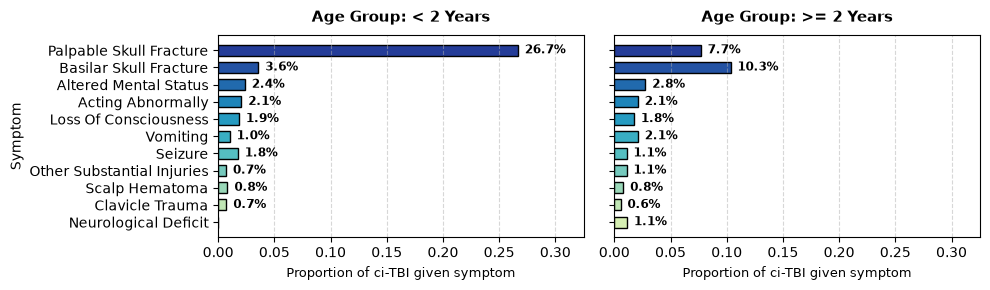

In [14]:
#| fig-cap: "Proportion of ci-TBI given presenting symptom stratified by age group"
risk_records = []

for age in age_groups:
    sub_df = train_data[train_data["age_group"] == age]
    for var in symptom_vars:
        if var in sub_df.columns:
            symptom_present = sub_df[sub_df[var] == 1]
            if len(symptom_present) > 0:
                prob = symptom_present["ci_tbi"].mean()
                risk_records.append({"symptom": var, "age_group": age, "ci_tbi_prob": float(prob)})

risk_df = pd.DataFrame(risk_records)
overall_order_risk = (risk_df.groupby("symptom")["ci_tbi_prob"].mean().sort_values(ascending=True).index.tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes = {age_groups[0]: ax1, age_groups[1]: ax2}
global_max_x = risk_df["ci_tbi_prob"].max()

for age in age_groups:
    ax = axes[age]
    age_data = (risk_df[risk_df["age_group"] == age].set_index("symptom").reindex(overall_order_risk).reset_index())
    age_data["clean_symptom"] = age_data["symptom"].map(clean_symptom_map)

    gradient_colors = plt.cm.YlGnBu(np.linspace(0.2, 0.85, len(age_data)))

    bars = ax.barh(age_data["clean_symptom"], age_data["ci_tbi_prob"], color=gradient_colors, edgecolor="black", height=0.65)

    for bar in bars:
        width = bar.get_width()
        if not np.isnan(width) and width > 0:
            ax.annotate(f"{width:.1%}", xy=(width, bar.get_y() + bar.get_height() / 2.0), xytext=(5, 0), textcoords="offset points", ha="left", va="center", fontsize=8.5, fontweight="bold")

    ax.set_title(f"Age Group: {age}", fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Proportion of ci-TBI given symptom", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    if not np.isnan(global_max_x) and global_max_x > 0:
        ax.set_xlim(0, global_max_x * 1.22)

ax1.set_ylabel("Symptom", fontsize=10)

plt.tight_layout()
plt.show()

## 3.3 Reality Check

So far, our results coincide with what we would expect in reality:
- Minor, more easily-identifiable symptoms are most prevalent in emergency department visit history. We speculate that such symptoms prompt the parent/guardian to report the child's condition to an emergency department.
- Additionally, abnormal actions, a symptom determined solely by the parents, may be inflated out of paranoia due to concern for the child. This further propagates the enrollment of low-risk children into emergency departments.
- Lastly, the clinician-identified symptoms of palpable skull fracture and basilar skull fracture have the highest proportion of children with ciTBI. These symptoms, which are directly related to damage to the head, are likely to be the highest-risk symptoms.

We are also able to validate some of our findings against an external study, with a few caveats. Güneysu et al.[3] conducted a validation of the Infant Scalp Score (ISS) at a single emergency department at Gazi University, defining ciTBI identically to PECARN (requiring a neurosurgical procedure, requiring at least 24 h of intubation, hospitalization for 2 or more nights due to head injury, or death). They analyzed patients under the age of two years with closed head injuries and scalp hematoma to address the same clinical goal of minimizing unnecessary radiation exposure from CT scans. Although the target demographic differs in geographical setting and specific inclusion scoring, Güneysu et al.[3] found that 1.3 percent of patients with scalp hematoma had ciTBI, and found vomiting to be a symptom in 10.3 percent of the patients. Our report obtained 0.8 percent and 10.3 percent for the two mentioned metrics, respectively. We recognize the limitations of this comparison, however, under the reasonable assumption that our dataset reflects closed head injuries, we may validate our cleaned data as a realistic representation of the target pediatric population.

## 3.4 Stability Check

To validate the stability of our findings, we aim to replicate our results with a perturbed version of our cleaned dataset. Recall our discussion on the use of the sub symptom variables rather than the indicator variables to impute the main symptom variables. We believe that our approach involves less uncertainty, thus, our findings using our approach is likely to be more aligned to reality. Nonetheless, if our findings are concrete in reality, we should observe similar statistics if we were to clean our data using the indicator variables as the ground truth.

The indicator variables are only marked as true if the symptom is a primary reason for ordering a CT scan. Therefore, even if the symptom is present, the indicator variable may still be marked as false. Cleaning the data with this caveat requires random or proportion-based imputation, which we deemed to be hazardous, thus we made the assumption that the indicator variables are only marked if the symptom is present. Furthermore, we made the decision to impute the variable `ActNorm` as false if the indicator variable `IndRqstParent`, which indicates if the CT scan is being ordered due to a parent's request, is true. 

In [16]:
alternative_train, alternative_val, alternative_test = clean.clean_data(data_split_train, data_split_val, data_split_test, True)

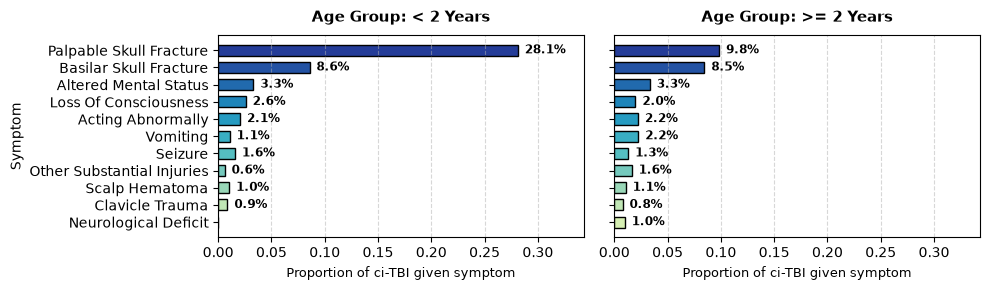

In [17]:
#| fig-cap: "Proportion of ci-TBI given presenting symptom stratified by age group - Alternative Cleaned Data"

# I just copied the code from the previous code cell, please let it slide
risk_records = []

for age in age_groups:
    sub_df = alternative_train[alternative_train["age_group"] == age]
    for var in symptom_vars:
        if var in sub_df.columns:
            symptom_present = sub_df[sub_df[var] == 1]
            if len(symptom_present) > 0:
                prob = symptom_present["ci_tbi"].mean()
                risk_records.append({"symptom": var, "age_group": age, "ci_tbi_prob": float(prob)})

risk_df = pd.DataFrame(risk_records)
overall_order_risk = (risk_df.groupby("symptom")["ci_tbi_prob"].mean().sort_values(ascending=True).index.tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes = {age_groups[0]: ax1, age_groups[1]: ax2}
global_max_x = risk_df["ci_tbi_prob"].max()

for age in age_groups:
    ax = axes[age]
    age_data = (risk_df[risk_df["age_group"] == age].set_index("symptom").reindex(overall_order_risk).reset_index())
    age_data["clean_symptom"] = age_data["symptom"].map(clean_symptom_map)

    gradient_colors = plt.cm.YlGnBu(np.linspace(0.2, 0.85, len(age_data)))

    bars = ax.barh(age_data["clean_symptom"], age_data["ci_tbi_prob"], color=gradient_colors, edgecolor="black", height=0.65)

    for bar in bars:
        width = bar.get_width()
        if not np.isnan(width) and width > 0:
            ax.annotate(f"{width:.1%}", xy=(width, bar.get_y() + bar.get_height() / 2.0), xytext=(5, 0), textcoords="offset points", ha="left", va="center", fontsize=8.5, fontweight="bold")

    ax.set_title(f"Age Group: {age}", fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Proportion of ci-TBI given symptom", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    if not np.isnan(global_max_x) and global_max_x > 0:
        ax.set_xlim(0, global_max_x * 1.22)

ax1.set_ylabel("Symptom", fontsize=10)

plt.tight_layout()
plt.show()

Figure 6 reveals the proportion of ciTBI diagnoses by age group by symptom. Because all of the variables show little to no change in numerical significance or value, we determine our findings to be stable under data perturbations. 

# 4 Modeling

In this section, we evaluate the predictive capabilities of two classical models, logistic regression and random forest, on our cleaned datasets. The original study utilized a relative cost of 500 to 1 for failure to identify a patient with ciTBI versus incorrect classification of a patient without ciTBI to maximize sensitivity and negative predictive value (NPV). We match their model setup by applying a grid search over relative costs of 1:1, 10:1, 50:1, 100:1, 500:1, and 1000:1, selecting the best relative cost using our validation set and evaluating it with the test set. Additionally, we applied a grid search for the inverse regularization strength (C) of the logistic regression models with values of 0.01, 0.1, 1.0, and 10.0, and a grid search for the depth of the random forest models with values of 3, 5, and 8. The best model was selected based on first maximizing sensitvity (to avoid false negatives i.e. missing a ciTBI diagnosis), then maximizing NPV. Predictors for the logistic regression model were set using indicator variables, and neurological deficit was dropped as a predictor due to complete separation for the younger age group.

## 4.1 Implementation

For the patients younger than two years of age, the logistic regression model chose a risk ratio of 500:1 and C = 1.0, achieving validation and test sensitivitys and NPVs of 100%. The random forest model chose a risk ratio of 500:1 and depth = 3, achieving a validation sensitivity of 87.50% and NPV of 99.48%, and a testing sensitivity of 100% and NPV of 100%. Looking at the coefficients for the logistic regression model (Table 2), the three most influential predictors are palpable skull fracture (5.5296), altered mental state (2.1824), and high injury severity (2.0620). The random forest model's feature importance plot (Figure 7), however, indicates that acting abnormally, altered mental status, and palpable skull fracture were the three most influential variables.

In [17]:
model_feature_cols = [
    "injury_severity",
    "altered_mental_status",
    "basilar_skull_fracture",
    "clavicle_trauma",
    "seizure",
    "other_substantial_injuries",
    "gcs_total",
    "vomiting",
    "scalp_hematoma",
    "palpable_skull_fracture",
    "gender",
    "loss_of_consciousness",
    "acting_abnormally",
]
target_col = "ci_tbi"

In [18]:
def prepare_age_split(data, age_val):
    """ 
    
    Filter dataset by age_group and return dummy-encoded X and y.
    
    Args:
        data (pd.DataFrame): Dataset to obtain variables from
        age_val (string): Age group (< 2 Years, >= 2 Years)
        
    Returns:
        tuple[pd.DataFrame, pd.Series]: A tuple (X,y) where:
            - X (pd.DataFrame): Subset of data containing only model_feature_cols
            - y (pd.Series): Binary labels corresponding to target_col
    """
    sub_data = data[data["age_group"] == age_val].copy()
    y = sub_data[target_col].astype(int)
    X = sub_data[model_feature_cols].copy()

    X = pd.get_dummies(X, columns=["gender"], drop_first=True, dtype=int)
    return X, y

def calculate_clinical_metrics(y_true, y_pred, y_probs):
    """ 
    Computes diagnostic performance metrics and confusion matrix counts: sensitivity, specificity, positive predictive value, negative predictive value, and AUC.
    
    Args:
        y_true (array-like): Ground truth binary labels
        y_pred (array-like): Predicted binary labels
        y_probs (array-like): Predicted probabilities for positive class (1)
        
    Returns:
        dict[str, float or int]: Dictionary containing evaluated performance metrics and confusion matrix counts.
        
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    auc = roc_auc_score(y_true, y_probs) if len(np.unique(y_true)) > 1 else 0.0

    return {
        "sensitivity": sensitivity,
        "npv": npv,
        "specificity": specificity,
        "ppv": ppv,
        "auc": auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

In [19]:
# Get unique age groups present in the data
age_groups = sorted(train_data["age_group"].unique())

data_splits = {}
for ag in age_groups:
    X_tr_raw, y_tr = prepare_age_split(train_data, ag)
    X_va_raw, y_va = prepare_age_split(val_data, ag)
    X_te_raw, y_te = prepare_age_split(test_data, ag)

    # One-hot encode "injury_severity"
    X_tr = pd.get_dummies(X_tr_raw, columns=["injury_severity"], drop_first=True)
    X_va = pd.get_dummies(X_va_raw, columns=["injury_severity"], drop_first=True).reindex(columns=X_tr.columns, fill_value=0)
    X_te = pd.get_dummies(X_te_raw, columns=["injury_severity"], drop_first=True).reindex(columns=X_tr.columns, fill_value=0)

    data_splits[ag] = {
        "X_train": X_tr,
        "y_train": y_tr,
        "X_val": X_va,
        "y_val": y_va,
        "X_test": X_te,
        "y_test": y_te,
    }

In [20]:
#| output: false
summary_results = []

# Grid search weighing for relative cost of misidentification
cost_weight_options = [
    "balanced",
    {0: 1, 1: 10},
    {0: 1, 1: 50},
    {0: 1, 1: 100},
    {0: 1, 1: 500},
    {0: 1, 1: 1000},
]
# Inverse regularization strength grid search
c_options = [0.01, 0.1, 1.0, 10.0]

best_lr_models = {}
lr_coef_dfs = []

for ag in age_groups:
    X_train, y_train = data_splits[ag]["X_train"], data_splits[ag]["y_train"]
    X_val, y_val = data_splits[ag]["X_val"], data_splits[ag]["y_val"]
    X_test, y_test = data_splits[ag]["X_test"], data_splits[ag]["y_test"]

    best_lr = None
    best_val_metrics = None
    best_sens, best_npv = -1.0, -1.0
    best_params = {}

    for weight in cost_weight_options:
        for c_val in c_options:
            lr = LogisticRegression(class_weight=weight, C=c_val, random_state=42, max_iter=1000)
            lr.fit(X_train, y_train)

            val_preds = lr.predict(X_val)
            val_probs = lr.predict_proba(X_val)[:, 1]
            val_metrics = calculate_clinical_metrics(y_val, val_preds, val_probs)

            # Save best model based on sensitivity and NPV
            has_valid_npv = val_metrics["npv"] > 0.0
            if has_valid_npv and ((val_metrics["sensitivity"], val_metrics["npv"]) > (best_sens, best_npv)):
                best_sens = val_metrics["sensitivity"]
                best_npv = val_metrics["npv"]
                best_lr = lr
                best_val_metrics = val_metrics
                best_params = {"class_weight": weight, "C": c_val}

    best_lr_models[ag] = best_lr

    test_preds = best_lr.predict(X_test)
    test_probs = best_lr.predict_proba(X_test)[:, 1]
    test_metrics = calculate_clinical_metrics(y_test, test_preds, test_probs)

    summary_results.append({
        "Model": "Logistic Regression",
        "Age Group": ag,
        "Val Sensitivity": best_val_metrics["sensitivity"],
        "Val NPV": best_val_metrics["npv"],
        "Val Specificity": best_val_metrics["specificity"],
        "Val PPV": best_val_metrics["ppv"],
        "Val AUC": best_val_metrics["auc"],
        "Test Sensitivity": test_metrics["sensitivity"],
        "Test NPV": test_metrics["npv"],
        "Test Specificity": test_metrics["specificity"],
        "Test PPV": test_metrics["ppv"],
        "Test AUC": test_metrics["auc"],
    })

    beta = np.append(best_lr.intercept_, best_lr.coef_[0])
    df_ag = pd.DataFrame({"Feature": ["(Intercept)"] + list(X_train.columns), f"Beta (Age {ag})": beta, f"Odds Ratio (Age {ag})": np.exp(beta),})
    lr_coef_dfs.append(df_ag)

    print(f"\n--- Age Group: {ag} ---")
    print(
        f"Best Hyperparams  : Weight={best_params['class_weight']}, C={best_params['C']}"
    )
    print(
        f"Validation        : Sens: {best_val_metrics['sensitivity']:.4%} | NPV: {best_val_metrics['npv']:.4%} | Spec: {best_val_metrics['specificity']:.4%} | PPV: {best_val_metrics['ppv']:.4%} | AUC: {best_val_metrics['auc']:.4%}"
    )
    print(
        f"Test              : Sens: {test_metrics['sensitivity']:.4%} | NPV: {test_metrics['npv']:.4%} | Spec: {test_metrics['specificity']:.4%} | PPV: {test_metrics['ppv']:.4%} | AUC: {test_metrics['auc']:.4%}"
    )


--- Age Group: < 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 500}, C=0.01
Validation        : Sens: 100.0000% | NPV: 100.0000% | Spec: 51.3816% | PPV: 1.2140% | AUC: 89.8385%
Test              : Sens: 100.0000% | NPV: 100.0000% | Spec: 51.9284% | PPV: 0.7112% | AUC: 92.4862%

--- Age Group: >= 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 500}, C=0.01
Validation        : Sens: 94.4444% | NPV: 99.9671% | Spec: 77.4325% | PPV: 1.8826% | AUC: 87.7292%
Test              : Sens: 90.0000% | NPV: 99.9331% | Spec: 78.1266% | PPV: 2.1077% | AUC: 92.1278%


In [21]:
#| fig-align: center
#| lst-cap: "Logistic Regression Coefficients Across Age Groups"
#| attr-output: 'style="font-size: 0.5em;"'

combined_lr_table = lr_coef_dfs[0]
for df_next in lr_coef_dfs[1:]:
    combined_lr_table = pd.merge(combined_lr_table, df_next, on="Feature", how="outer")

formatted_lr_table = combined_lr_table.copy()
numeric_cols = [c for c in formatted_lr_table.columns if c != "Feature"]
for col in numeric_cols:
    formatted_lr_table[col] = formatted_lr_table[col].map(lambda x: f"{x:6.4f}")

raw_latex = formatted_lr_table.to_latex(index=False, escape=True)

scaled_latex_table = f"""
\\begin{{table}}[h]
\\centering
\\scriptsize
\\begin{{adjustbox}}{{max width=\\textwidth}}
{raw_latex}
\\end{{adjustbox}}
\\captionsetup{{font=tiny}}
\\caption{{Logistic Regression Coefficients Across Age Groups}}
\\end{{table}}
"""

display(Latex(scaled_latex_table))

<IPython.core.display.Latex object>

For the patients greater than or equal to two years of age, the logistic regression model chose a risk ratio of 500:1 and C = 0.01, achieving a validation sensitivity of 94.44% and NPV of 99.97% and testing sensitivity of 90% and NPV of 99.93%. The random forest model chose a risk ratio of 500:1 and depth = 3, achieving a validation sensitivity of 94.44% and NPV of 99.96%, and a testing sensitivity of 90% and NPV of 99.92%. Looking at the coefficients for the logistic regression model (Table 2), the three most influential predictors are basilar skull fracture (3.0414), vomiting (2.0452), and palpable skull fracture (1.9643). The random forest model's feature importance plot (Figure 7), however, indicates that altered mental status, acting abnormally, and vomiting were the three most influential variables.

In [22]:
#| output: false
# Grid search for forest depth
max_depth_options = [3, 5, 8]
best_rf_models = {}

for ag in age_groups:
    X_train, y_train = data_splits[ag]["X_train"], data_splits[ag]["y_train"]
    X_val, y_val = data_splits[ag]["X_val"], data_splits[ag]["y_val"]
    X_test, y_test = data_splits[ag]["X_test"], data_splits[ag]["y_test"]

    best_rf = None
    best_val_metrics = None
    best_sens, best_npv = -1.0, -1.0
    best_params = {}

    for weight in cost_weight_options:
        for depth in max_depth_options:
            rf = RandomForestClassifier(n_estimators=100, max_depth=depth, class_weight=weight, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)

            val_preds = rf.predict(X_val)
            val_probs = rf.predict_proba(X_val)[:, 1]
            val_metrics = calculate_clinical_metrics(y_val, val_preds, val_probs)

            # Save best model based on sensitivity and NPV
            has_valid_npv = val_metrics["npv"] > 0.0
            if has_valid_npv and ((val_metrics["sensitivity"], val_metrics["npv"]) > (best_sens, best_npv)):
                best_sens = val_metrics["sensitivity"]
                best_npv = val_metrics["npv"]
                best_rf = rf
                best_val_metrics = val_metrics
                best_params = {"class_weight": weight, "max_depth": depth}

    best_rf_models[ag] = best_rf

    test_preds = best_rf.predict(X_test)
    test_probs = best_rf.predict_proba(X_test)[:, 1]
    test_metrics = calculate_clinical_metrics(y_test, test_preds, test_probs)

    # Store for performance summary
    summary_results.append({
        "Model": "Random Forest",
        "Age Group": ag,
        "Val Sensitivity": best_val_metrics["sensitivity"],
        "Val NPV": best_val_metrics["npv"],
        "Val Specificity": best_val_metrics["specificity"],
        "Val PPV": best_val_metrics["ppv"],
        "Val AUC": best_val_metrics["auc"],
        "Test Sensitivity": test_metrics["sensitivity"],
        "Test NPV": test_metrics["npv"],
        "Test Specificity": test_metrics["specificity"],
        "Test PPV": test_metrics["ppv"],
        "Test AUC": test_metrics["auc"],
    })

    print(f"\n--- Age Group: {ag} ---")
    print(
        f"Best Hyperparams  : Weight={best_params['class_weight']}, Depth={best_params['max_depth']}"
    )
    print(
        f"Validation        : Sens: {best_val_metrics['sensitivity']:.4%} | NPV: {best_val_metrics['npv']:.4%} | Spec: {best_val_metrics['specificity']:.4%} | PPV: {best_val_metrics['ppv']:.4%} | AUC: {best_val_metrics['auc']:.4%}"
    )
    print(
        f"Test              : Sens: {test_metrics['sensitivity']:.4%} | NPV: {test_metrics['npv']:.4%} | Spec: {test_metrics['specificity']:.4%} | PPV: {test_metrics['ppv']:.4%} | AUC: {test_metrics['auc']:.4%}"
    )


--- Age Group: < 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 500}, Depth=3
Validation        : Sens: 100.0000% | NPV: 100.0000% | Spec: 0.5975% | PPV: 0.5975% | AUC: 85.9270%
Test              : Sens: 100.0000% | NPV: 100.0000% | Spec: 0.9642% | PPV: 0.3465% | AUC: 92.3760%

--- Age Group: >= 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 500}, Depth=3
Validation        : Sens: 94.4444% | NPV: 99.9608% | Spec: 65.0025% | PPV: 1.2221% | AUC: 83.9821%
Test              : Sens: 90.0000% | NPV: 99.9208% | Spec: 65.9864% | PPV: 1.3657% | AUC: 89.9065%


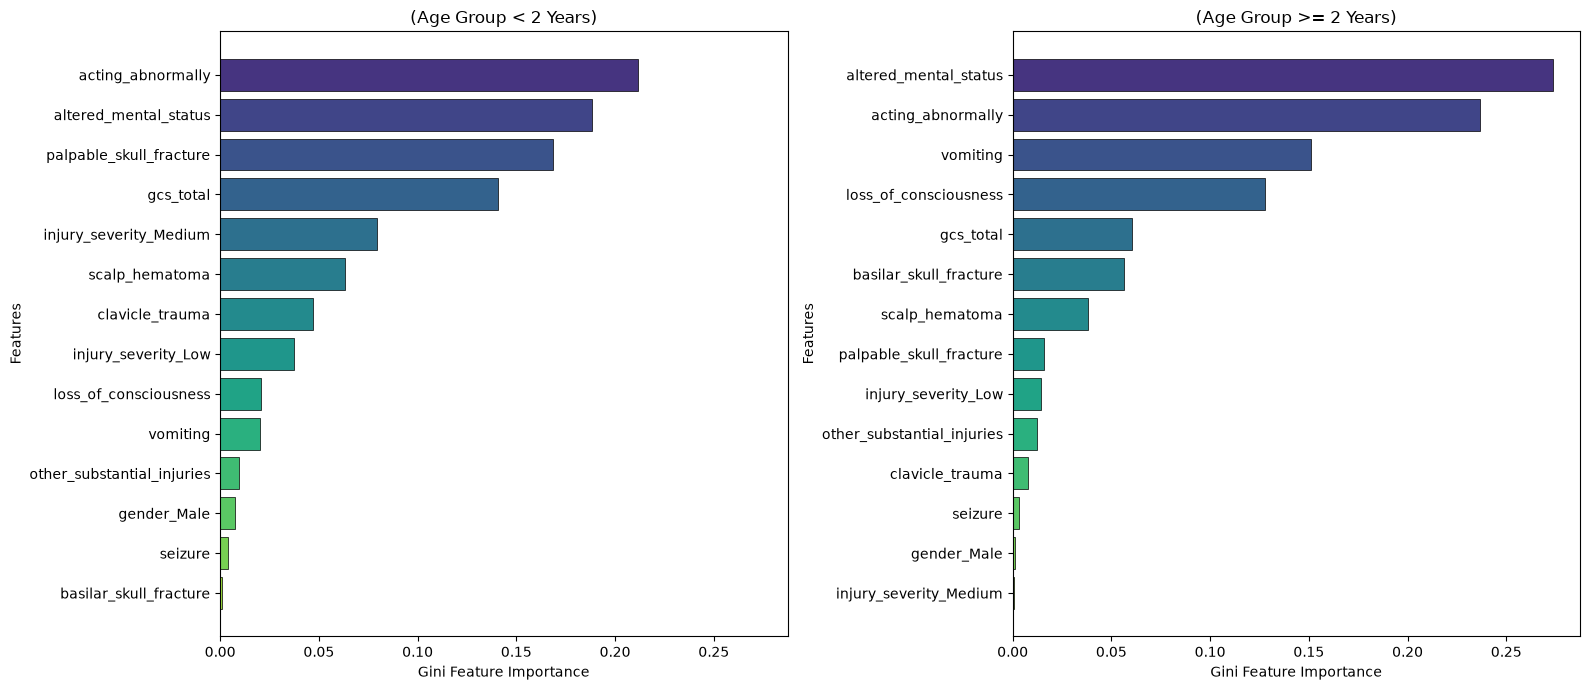

In [23]:
#| fig-cap: "Random Forest Feature Importance"
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

for idx, ag in enumerate(age_groups):
    rf_model = best_rf_models[ag]
    feature_names = data_splits[ag]["X_train"].columns
    importances = rf_model.feature_importances_

    imp_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=True))

    num_features = len(imp_df)
    bar_colors = plt.cm.viridis(np.linspace(0.85, 0.15, num_features))

    axes[idx].barh(imp_df["Feature"], imp_df["Importance"], color=bar_colors, edgecolor="black", linewidth=0.5)
    axes[idx].set_title(f"(Age Group {ag})", fontsize=12)
    axes[idx].set_xlabel("Gini Feature Importance")
    axes[idx].set_ylabel("Features")

plt.tight_layout()
plt.show()

## 4.2 Implementation Stability

To test the stability of our model results, we implement the two models with the same setup given our alternative cleaned datasets. 

For the patients younger than two years of age, the logistic regression model chose a risk ratio of 500:1 and C = 10.0, achieving a validation sensitivity of 88.89% and NPV of 99.87% and testing sensitivity of 85.71% and NPV of 99.88%. The random forest model chose a risk ratio of 500:1 and depth = 3, achieving a validation sensitivity and NPV of 100%, and a testing sensitivity of 85.71% and NPV of 99.60%. Looking at the coefficients for the logistic regression model (Table 3), the three most influential predictors are palpable skull fracture (4.8824), high injury severity (2.3816), and altered mental status (2.2497). The random forest model's feature importance plot (Figure 8), however, indicates that  altered mental status, total GCS score and high injury severity were the three most influential variables.

For the patients greater than or equal to two years of age, the logistic regression model chose a risk ratio of 1000:1 and C = 0.01, achieving validation and testing sensitivities and NPVs of 100%. The random forest model chose a risk ratio of 500:1 and depth = 5, achieving a validation sensitivity of 94.44% and NPV of 99.96%, and a testing sensitivity of 90% and NPV of 99.92%. Looking at the coefficients for the logistic regression model (Table 3), the three most influential predictors are basilar skull fracture (2.7413), high injury severity (2.1492), and palpable skull fracture (2.0187). The random forest model's feature importance plot (Figure 8), however, indicates that altered mental status, vomiting, and acting abnormally were the three most influential variables.

In [24]:
# I just copied the code from the earlier section instead of making a function please forgive me.
age_groups = sorted(train_data["age_group"].unique())

data_splits = {}
for ag in age_groups:
    X_tr_raw, y_tr = prepare_age_split(alternative_train, ag)
    X_va_raw, y_va = prepare_age_split(alternative_val, ag)
    X_te_raw, y_te = prepare_age_split(alternative_test, ag)

    X_tr = pd.get_dummies(X_tr_raw, columns=["injury_severity"], drop_first=True)
    X_va = pd.get_dummies(X_va_raw, columns=["injury_severity"], drop_first=True).reindex(columns=X_tr.columns, fill_value=0)
    X_te = pd.get_dummies(X_te_raw, columns=["injury_severity"], drop_first=True).reindex(columns=X_tr.columns, fill_value=0)

    data_splits[ag] = {
        "X_train": X_tr,
        "y_train": y_tr,
        "X_val": X_va,
        "y_val": y_va,
        "X_test": X_te,
        "y_test": y_te,
    }

In [25]:
#| output: false
summary_results = []

cost_weight_options = [
    "balanced",
    {0: 1, 1: 10},
    {0: 1, 1: 50},
    {0: 1, 1: 100},
    {0: 1, 1: 500},
    {0: 1, 1: 1000},
]
c_options = [0.01, 0.1, 1.0, 10.0]

best_lr_models = {}
lr_coef_dfs = []

for ag in age_groups:
    X_train, y_train = data_splits[ag]["X_train"], data_splits[ag]["y_train"]
    X_val, y_val = data_splits[ag]["X_val"], data_splits[ag]["y_val"]
    X_test, y_test = data_splits[ag]["X_test"], data_splits[ag]["y_test"]

    best_lr = None
    best_val_metrics = None
    best_sens, best_npv = -1.0, -1.0
    best_params = {}

    for weight in cost_weight_options:
        for c_val in c_options:
            lr = LogisticRegression(class_weight=weight, C=c_val, random_state=42, max_iter=1000)
            lr.fit(X_train, y_train)

            val_preds = lr.predict(X_val)
            val_probs = lr.predict_proba(X_val)[:, 1]
            val_metrics = calculate_clinical_metrics(y_val, val_preds, val_probs)

            has_valid_npv = val_metrics["npv"] > 0.0
            if has_valid_npv and ((val_metrics["sensitivity"], val_metrics["npv"]) > (best_sens, best_npv)):
                best_sens = val_metrics["sensitivity"]
                best_npv = val_metrics["npv"]
                best_lr = lr
                best_val_metrics = val_metrics
                best_params = {"class_weight": weight, "C": c_val}

    best_lr_models[ag] = best_lr

    test_preds = best_lr.predict(X_test)
    test_probs = best_lr.predict_proba(X_test)[:, 1]
    test_metrics = calculate_clinical_metrics(y_test, test_preds, test_probs)

    summary_results.append({
        "Model": "Logistic Regression",
        "Age Group": ag,
        "Val Sensitivity": best_val_metrics["sensitivity"],
        "Val NPV": best_val_metrics["npv"],
        "Val Specificity": best_val_metrics["specificity"],
        "Val PPV": best_val_metrics["ppv"],
        "Val AUC": best_val_metrics["auc"],
        "Test Sensitivity": test_metrics["sensitivity"],
        "Test NPV": test_metrics["npv"],
        "Test Specificity": test_metrics["specificity"],
        "Test PPV": test_metrics["ppv"],
        "Test AUC": test_metrics["auc"],
    })

    beta = np.append(best_lr.intercept_, best_lr.coef_[0])
    df_ag = pd.DataFrame({"Feature": ["(Intercept)"] + list(X_train.columns), f"Beta (Age {ag})": beta, f"Odds Ratio (Age {ag})": np.exp(beta),})
    lr_coef_dfs.append(df_ag)

    print(f"\n--- Age Group: {ag} ---")
    print(
        f"Best Hyperparams  : Weight={best_params['class_weight']}, C={best_params['C']}"
    )
    print(
        f"Validation        : Sens: {best_val_metrics['sensitivity']:.4%} | NPV: {best_val_metrics['npv']:.4%} | Spec: {best_val_metrics['specificity']:.4%} | PPV: {best_val_metrics['ppv']:.4%} | AUC: {best_val_metrics['auc']:.4%}"
    )
    print(
        f"Test              : Sens: {test_metrics['sensitivity']:.4%} | NPV: {test_metrics['npv']:.4%} | Spec: {test_metrics['specificity']:.4%} | PPV: {test_metrics['ppv']:.4%} | AUC: {test_metrics['auc']:.4%}"
    )


--- Age Group: < 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 1000}, C=0.01
Validation        : Sens: 100.0000% | NPV: 100.0000% | Spec: 23.8913% | PPV: 0.8388% | AUC: 78.4414%
Test              : Sens: 85.7143% | NPV: 99.7175% | Spec: 23.5805% | PPV: 0.5217% | AUC: 82.2550%

--- Age Group: >= 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 1000}, C=0.01
Validation        : Sens: 93.3333% | NPV: 99.9045% | Spec: 49.0509% | PPV: 1.2716% | AUC: 87.5537%
Test              : Sens: 97.0588% | NPV: 99.9513% | Spec: 48.8810% | PPV: 1.5138% | AUC: 91.7010%


In [26]:
#| fig-align: center
#| lst-cap: "Logistic Regression Coefficients Across Age Groups"
#| attr-output: 'style="font-size: 0.5em;"'

combined_lr_table = lr_coef_dfs[0]
for df_next in lr_coef_dfs[1:]:
    combined_lr_table = pd.merge(combined_lr_table, df_next, on="Feature", how="outer")

formatted_lr_table = combined_lr_table.copy()
numeric_cols = [c for c in formatted_lr_table.columns if c != "Feature"]
for col in numeric_cols:
    formatted_lr_table[col] = formatted_lr_table[col].map(lambda x: f"{x:6.4f}")

raw_latex = formatted_lr_table.to_latex(index=False, escape=True)

scaled_latex_table = f"""
\\begin{{table}}[h]
\\centering
\\scriptsize
\\begin{{adjustbox}}{{max width=\\textwidth}}
{raw_latex}
\\end{{adjustbox}}
\\captionsetup{{font=tiny}}
\\caption{{Logistic Regression Coefficients Across Age Groups - Alternative Cleaned Data}}
\\end{{table}}
"""

display(Latex(scaled_latex_table))

<IPython.core.display.Latex object>

In [27]:
#| output: false
max_depth_options = [3, 5, 8]
best_rf_models = {}

for ag in age_groups:
    X_train, y_train = data_splits[ag]["X_train"], data_splits[ag]["y_train"]
    X_val, y_val = data_splits[ag]["X_val"], data_splits[ag]["y_val"]
    X_test, y_test = data_splits[ag]["X_test"], data_splits[ag]["y_test"]

    best_rf = None
    best_val_metrics = None
    best_sens, best_npv = -1.0, -1.0
    best_params = {}

    for weight in cost_weight_options:
        for depth in max_depth_options:
            rf = RandomForestClassifier(n_estimators=100, max_depth=depth, class_weight=weight, random_state=42, n_jobs=-1)
            rf.fit(X_train, y_train)

            val_preds = rf.predict(X_val)
            val_probs = rf.predict_proba(X_val)[:, 1]
            val_metrics = calculate_clinical_metrics(y_val, val_preds, val_probs)

            has_valid_npv = val_metrics["npv"] > 0.0
            if has_valid_npv and ((val_metrics["sensitivity"], val_metrics["npv"]) > (best_sens, best_npv)):
                best_sens = val_metrics["sensitivity"]
                best_npv = val_metrics["npv"]
                best_rf = rf
                best_val_metrics = val_metrics
                best_params = {"class_weight": weight, "max_depth": depth}

    best_rf_models[ag] = best_rf

    test_preds = best_rf.predict(X_test)
    test_probs = best_rf.predict_proba(X_test)[:, 1]
    test_metrics = calculate_clinical_metrics(y_test, test_preds, test_probs)

    summary_results.append({
        "Model": "Random Forest",
        "Age Group": ag,
        "Val Sensitivity": best_val_metrics["sensitivity"],
        "Val NPV": best_val_metrics["npv"],
        "Val Specificity": best_val_metrics["specificity"],
        "Val PPV": best_val_metrics["ppv"],
        "Val AUC": best_val_metrics["auc"],
        "Test Sensitivity": test_metrics["sensitivity"],
        "Test NPV": test_metrics["npv"],
        "Test Specificity": test_metrics["specificity"],
        "Test PPV": test_metrics["ppv"],
        "Test AUC": test_metrics["auc"],
    })

    print(f"\n--- Age Group: {ag} ---")
    print(
        f"Best Hyperparams  : Weight={best_params['class_weight']}, Depth={best_params['max_depth']}"
    )
    print(
        f"Validation        : Sens: {best_val_metrics['sensitivity']:.4%} | NPV: {best_val_metrics['npv']:.4%} | Spec: {best_val_metrics['specificity']:.4%} | PPV: {best_val_metrics['ppv']:.4%} | AUC: {best_val_metrics['auc']:.4%}"
    )
    print(
        f"Test              : Sens: {test_metrics['sensitivity']:.4%} | NPV: {test_metrics['npv']:.4%} | Spec: {test_metrics['specificity']:.4%} | PPV: {test_metrics['ppv']:.4%} | AUC: {test_metrics['auc']:.4%}"
    )


--- Age Group: < 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 500}, Depth=3
Validation        : Sens: 100.0000% | NPV: 100.0000% | Spec: 0.5722% | PPV: 0.6433% | AUC: 80.1184%
Test              : Sens: 85.7143% | NPV: 93.3333% | Spec: 0.9352% | PPV: 0.4030% | AUC: 72.9125%

--- Age Group: >= 2 Years ---
Best Hyperparams  : Weight={0: 1, 1: 500}, Depth=3
Validation        : Sens: 100.0000% | NPV: 100.0000% | Spec: 4.6168% | PPV: 0.7317% | AUC: 84.1063%
Test              : Sens: 100.0000% | NPV: 100.0000% | Spec: 4.0238% | PPV: 0.8364% | AUC: 87.5609%


Despite the difference in data imputation method, the model results remain stable, achieving high sensitivity and NPV values. For the logistic regression models, the original and alternative models for the younger age group agree on the top three most influential features, and the top three features for the original older group model are within the top five features of the alternative older group model. Similar results can be observed in the random forest models, as the models for the older age group have the same top three features, and the top three features for the original younger group model are within the top six features of the alternative model. As such, our findings are resilient to data perturbations.

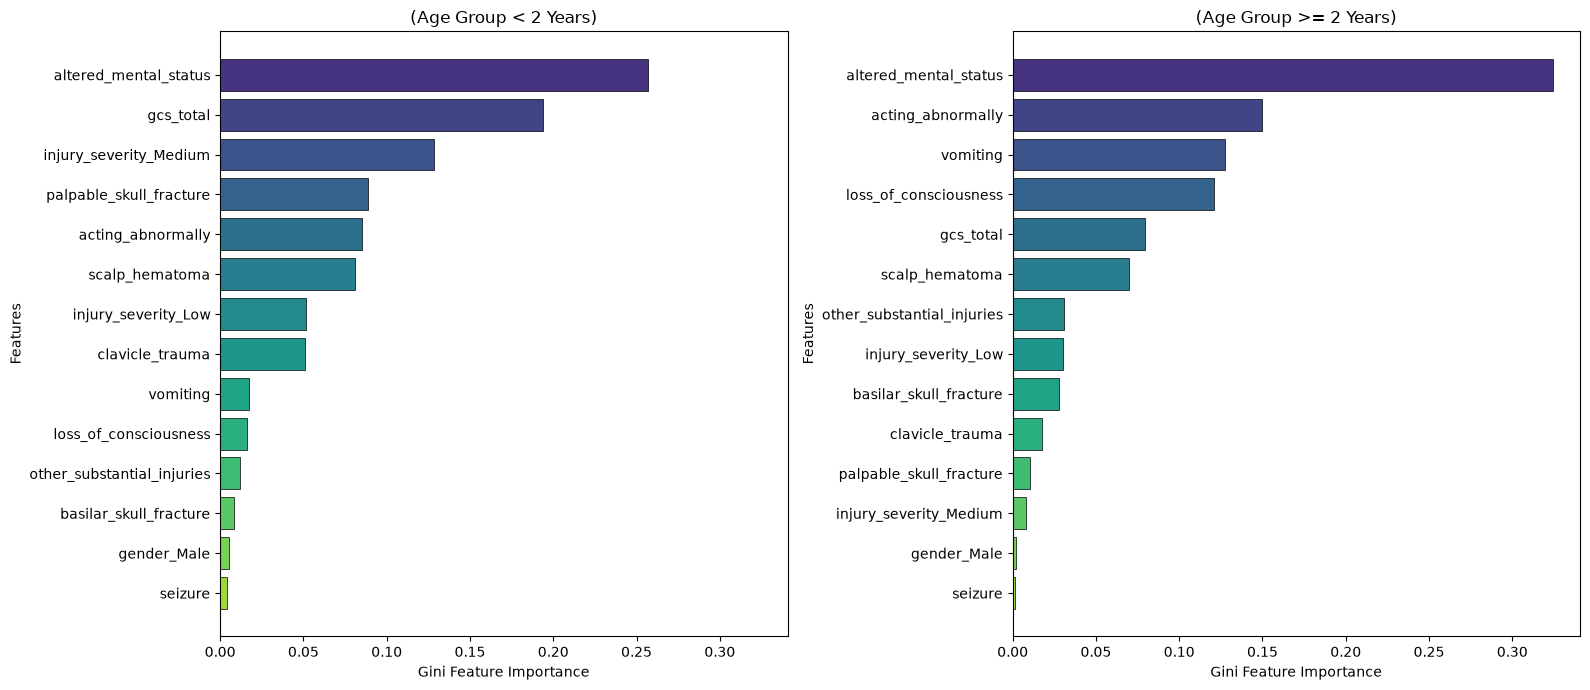

In [28]:
#| fig-cap: "Random Forest Feature Importance - Alternative Cleaned Data"
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

for idx, ag in enumerate(age_groups):
    rf_model = best_rf_models[ag]
    feature_names = data_splits[ag]["X_train"].columns
    importances = rf_model.feature_importances_

    imp_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=True))

    num_features = len(imp_df)
    bar_colors = plt.cm.viridis(np.linspace(0.85, 0.15, num_features))

    axes[idx].barh(imp_df["Feature"], imp_df["Importance"], color=bar_colors, edgecolor="black", linewidth=0.5)
    axes[idx].set_title(f"(Age Group {ag})", fontsize=12)
    axes[idx].set_xlabel("Gini Feature Importance")
    axes[idx].set_ylabel("Features")

plt.tight_layout()
plt.show()

## 4.3 Discussion

We chose to implement the logistic regression and random forest models because of their interpretability. Rather than forcing perfect 100% sensitivity and NPV using powerful, black-box machine learning models, we believe it is more curcial for clinicians to have access to an interpretable model that provides a better understanding of the symptoms. Although some of our models fall short of achieving 100% sensitivities and NPVs, our model results affirm the effectiveness of the prediction rules established by the PECARN cohort. We were able to replicate their results in achieving high sensitivity and NPV models, and confirmed the significance of the symptoms utilized in their predictive rules. Furthermore, our models suggest that basilar skull fracture and vomiting may be significant predictors that could further enhance the predictive rules' performance.

# 5 Conclusion

The size of the PECARN TBI dataset is a remarkable achievement, however, we believe that a larger dataset is necessary for a proper approximation of reality. The issue of complete separation with the neurological deficit variable in our analysis, although partly due to chance, is a sign that we do not have enough data to generalize our and the PECARN study's results to the target pediatric population. Furthermore, during our data exploration and cleaning, we observed several cases in which the sample size of patients with a specific combination of symptoms was too low to make reasonable statistical conclusions on. The low sample size for such cases likely reflects reality with their low probabilities of occurrence, yet it does not excuse the possiblity that our decision rules could be flawed for these groups. 

Despite these limitations, applying the PCS principles throughout this report has revealed to us the importance of upholding proper data analysis procedures. Data analysis is fundamentally restricted from the truth as data is an approximation of reality. However, through careful and iterative investigation of the data throughout the data science life cycle, we are able to develop mental constructs in the form of statistical models and explanatory visualizations that accurately capture trends within the data. Through this procedure, we have validated the PECARN study's results and suggested additional symptoms to consider for their predictive rules.

# 6 Academic Honesty Statement

Here, I declare that this report represents my original work completed for this course. All data processing, model implementation, and written interpretations were conducted in accordance with the university and course academic integrity policies. Where external research and datasets were utilized, they have been properly credited and cited.

As researchers, it is imperative that we remain truthful about our work, as a lack of honesty can inhibit collaborative progress. Our collective knowledge only progresses when genuine, original work is added to the pool, rather than findings that are plagiarized or manipulated in pursuit of success. Hence, maintaining integrity is essential.

# 7 Collaborators

Ideas for data cleaning and exploration were discussed with Brileigh Cates, Matthew Eichner, Peter Zakariya, and Prithika Roy. LLMs were used to provide suggestions for customizing the plots and tables, and for applying Quarto.

# 8 Bibliography

[1] Babl FE, Borland ML, Phillips N, et al. Paediatric Research in Emergency Departments International Collaborative (PREDICT) pediatric head injury study protocol: a multicentre observational study in Australia and New Zealand. BMC Pediatr. 2016;16(1):122. doi:10.1186/s12889-016-3529-y

[2] Kuppermann N, Holmes JF, Dayan PS, et al. Identification of children at very low risk of clinically-important brain injuries after head trauma: a prospective cohort study. Lancet. 2009;374(9696):1160-1170. doi:10.1016/S0140-6736(09)61558-0

[3] Burstein B, Yaghoubi M. External validation and performance of pediatric head trauma clinical decision rules: a systematic review and meta-analysis. Eur J Trauma Emerg Surg. 2023;49(2):651-663. doi:10.1007/s00068-022-02085-9